# Task 1 — SNCF Train Punctuality Classification
**Author:** Ahmed Al-Muharaq  
**Master 1 — LAS | Machine Learning for IoT**  
**Supervisor:** Michel Salomon | michel.salomon@umlp.fr  


---

## Objective

Apply supervised Machine Learning to **predict the punctuality class** of TER (regional trains) services across French regions, based on operational data (scheduled trains, cancellations, delays).  

This replaces the original IoT data with **SNCF Open Data** covering 31 French regions from 2013 to 2026.

### Problem Framing
| | |
|---|---|
| **Task type** | Multi-class Classification |
| **Target** | Punctuality class: `Low` / `Medium` / `High` |
| **Input features** | Region, date (year/month/season), train counts, cancellation rate, delay rate |
| **Dataset** | `regularite_ter.csv` only — 2,273 rows, 9 columns |
| **Models** | Logistic Regression · Decision Tree · Random Forest · Gradient Boosting |

---

  ##    Table of Contents
1. Setup & Imports
2. Data Loading & Initial Exploration
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Preprocessing
5. Train / Test Split
6. Model Training
7. Model Evaluation & Comparison
8. Feature Importance
9. Key Findings & Possible Improvements
10. Final Conclusion

---
## 1. Setup & Imports <a id='setup'></a>

In [ ]:
# ── Standard libraries ──────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-Learn — preprocessing ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# ── Scikit-Learn — models ─────────────────────────────────────────────────────
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier

# ── Scikit-Learn — metrics ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

# ── Global settings ───────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)

# Seaborn theme — clean & professional
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = ['#2196F3', '#FF9800', '#4CAF50']   # blue / orange / green
SEED    = 42

print('✅  All libraries imported successfully.')

✅  All libraries imported successfully.


> **Note (Google Colab):** If running in Colab, mount your Drive first and update `DATA_PATH` below.

In [ ]:
# ── Path configuration ────────────────────────────────────────────────────────
# Set to the local folder where we uploaded the CSV
DATA_PATH = 'data/'

# Helper to build full path
def data(fname):
    return os.path.join(DATA_PATH, fname)

print(f'✅ Data directory set to: {os.path.abspath(DATA_PATH)}')

✅ Data directory set to: /content/data


In [ ]:
# ── Manual Data Upload ────────────────────────────────────────────────────────


from google.colab import files
import os

# Ensure the directory exists
os.makedirs('data', exist_ok=True)

print("Please upload 'regularite_ter.csv' below:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Move the file into the 'data/' folder
    os.rename(filename, os.path.join('data', filename))
    print(f'\n✅ Successfully uploaded and moved: {filename} to data/')

DATA_PATH = 'data/'

Please upload 'regularite_ter.csv' below:


Saving regularite_ter.csv to regularite_ter.csv

✅ Successfully uploaded and moved: regularite_ter.csv to data/


---
## 2. Data Loading & Initial Exploration <a id='loading'></a>

In [ ]:
# ── Load TER monthly punctuality dataset ─────────────────────────────────────
df_raw = pd.read_csv(data('regularite_ter.csv'), sep=';', encoding='utf-8')

print(f'Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print()
df_raw.info()

Shape  : 2,310 rows × 9 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2310 entries, 0 to 2309
Data columns (total 9 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   date                                                            2310 non-null   object 
 1   region                                                          2310 non-null   object 
 2   nombre_de_trains_programmes                                     2273 non-null   float64
 3   nombre_de_trains_ayant_circule                                  2273 non-null   float64
 4   nombre_de_trains_annules                                        2273 non-null   float64
 5   nombre_de_trains_en_retard_a_l_arrivee                          2273 non-null   float64
 6   taux_de_regularite                                              2273 non-null   float64
 7   nombre_de_trains_a_

In [ ]:
# ── First look at the data ────────────────────────────────────────────────────
df_raw.head(10)

,date,region,nombre_de_trains_programmes,nombre_de_trains_ayant_circule,nombre_de_trains_annules,nombre_de_trains_en_retard_a_l_arrivee,taux_de_regularite,nombre_de_trains_a_l_heure_pour_un_train_en_retard_a_l_arrivee,commentaires
0,2013-01,Nord Pas de Calais,19227.000,18890.000,337.000,2332.000,87.655,7.100,Vol de câble à Lille Sud.
1,2013-01,Lorraine,NaN,NaN,NaN,NaN,NaN,NaN,Le Président de la Région Lorraine s'est oppos...
2,2013-02,Basse Normandie,3013.000,2991.000,22.000,185.000,93.815,15.168,Nombreuses difficultés de circulation et plusi...
3,2013-02,Champagne Ardenne,5801.000,5763.000,38.000,233.000,95.957,23.734,NaN
4,2013-02,Limousin,3449.000,3406.000,43.000,219.000,93.570,14.553,NaN
5,2013-02,Nord Pas de Calais,17478.000,17228.000,250.000,1040.000,93.963,15.565,Intempéries mi-février.
6,2013-02,Poitou Charentes,3014.000,2991.000,23.000,118.000,96.055,24.347,NaN
7,2013-03,Bretagne,8363.000,8208.000,155.000,924.000,88.743,7.883,Perte de régularité supérieure à 6 points en g...
8,2013-03,Centre,9633.000,9446.000,187.000,634.000,93.288,13.899,NaN
9,2013-03,Franche Comté,5676.000,5628.000,48.000,360.000,93.603,14.633,NaN


In [ ]:
# ── Descriptive statistics ────────────────────────────────────────────────────
df_raw.describe()

,nombre_de_trains_programmes,nombre_de_trains_ayant_circule,nombre_de_trains_annules,nombre_de_trains_en_retard_a_l_arrivee,taux_de_regularite,nombre_de_trains_a_l_heure_pour_un_train_en_retard_a_l_arrivee
count,2273.000,2273.000,2273.000,2273.000,2273.000,2273.000
mean,13454.231,13175.278,297.072,1121.715,91.486,12.748
std,9915.524,9694.553,318.547,910.681,3.324,5.914
min,1129.000,1125.000,4.000,35.000,74.366,2.901
25%,6951.000,6823.000,93.000,469.000,89.620,8.636
50%,10440.000,10251.000,182.000,807.000,91.896,11.340
75%,15481.000,15183.000,392.000,1461.000,93.964,15.567
max,49194.000,48203.000,4024.000,5250.000,98.026,49.671


                                                    Missing  Pct (%)
commentaires                                           1384   59.910
nombre_de_trains_ayant_circule                           37    1.600
nombre_de_trains_programmes                              37    1.600
nombre_de_trains_annules                                 37    1.600
nombre_de_trains_en_retard_a_l_arrivee                   37    1.600
taux_de_regularite                                       37    1.600
nombre_de_trains_a_l_heure_pour_un_train_en_ret...       37    1.600


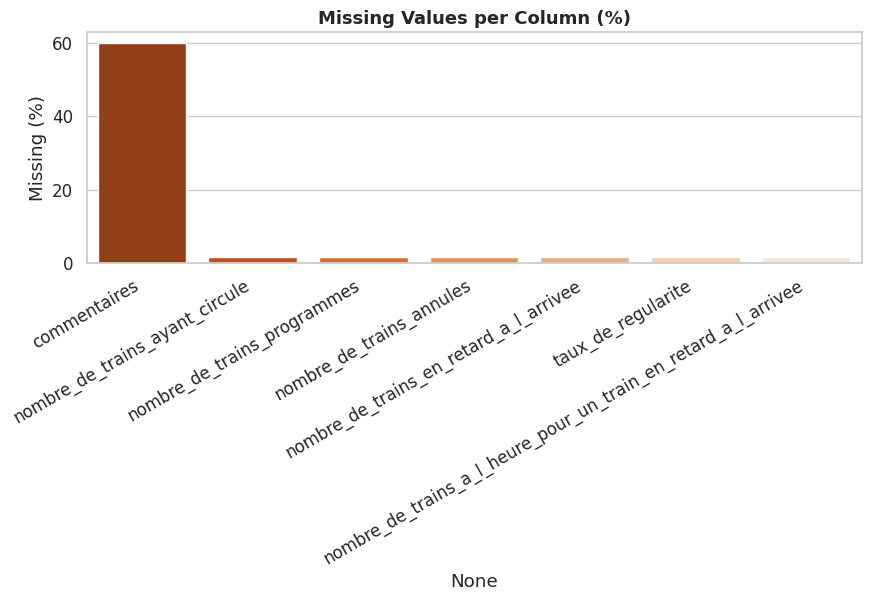

In [ ]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

miss_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
miss_df = miss_df[miss_df['Missing'] > 0].sort_values('Missing', ascending=False)
print(miss_df)

fig, ax = plt.subplots(figsize=(10, 3))
sns.barplot(x=miss_df.index, y=miss_df['Pct (%)'], palette='Oranges_r', ax=ax)
ax.set_title('Missing Values per Column (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ── Region overview ───────────────────────────────────────────────────────────
print(f"📍 Regions: {df_raw['region'].nunique()} unique")
print()
print(df_raw['region'].value_counts().to_string())

📍 Regions: 31 unique

region
Bretagne                      159
Pays-de-la-Loire              159
Provence Alpes Côte d'Azur    159
Grand Est                     111
Bourgogne-Franche-Comté        99
Normandie                      99
Auvergne-Rhône-Alpes           99
Hauts-de-France                99
Occitanie                      93
Aquitaine                      92
Centre                         92
Nouvelle Aquitaine             67
Centre Val-de-Loire            67
Midi Pyrénées                  66
Basse Normandie                60
Nord Pas de Calais             60
Bourgogne                      60
Auvergne                       60
Franche Comté                  60
Poitou Charentes               60
Limousin                       60
Rhône Alpes                    60
Haute Normandie                60
Languedoc Roussillon           60
Picardie                       60
Lorraine                       48
Champagne Ardenne              48
Alsace                         48
Loire Océan        

---
## 3. Exploratory Data Analysis (EDA) <a id='eda'></a>

In [ ]:
# Work on a clean copy; drop rows where the key target column is NaN
df = df_raw.dropna(subset=['taux_de_regularite']).copy()
print(f'Working dataset: {df.shape[0]:,} rows after removing {df_raw.shape[0] - df.shape[0]} NaN target rows')

Working dataset: 2,273 rows after removing 37 NaN target rows


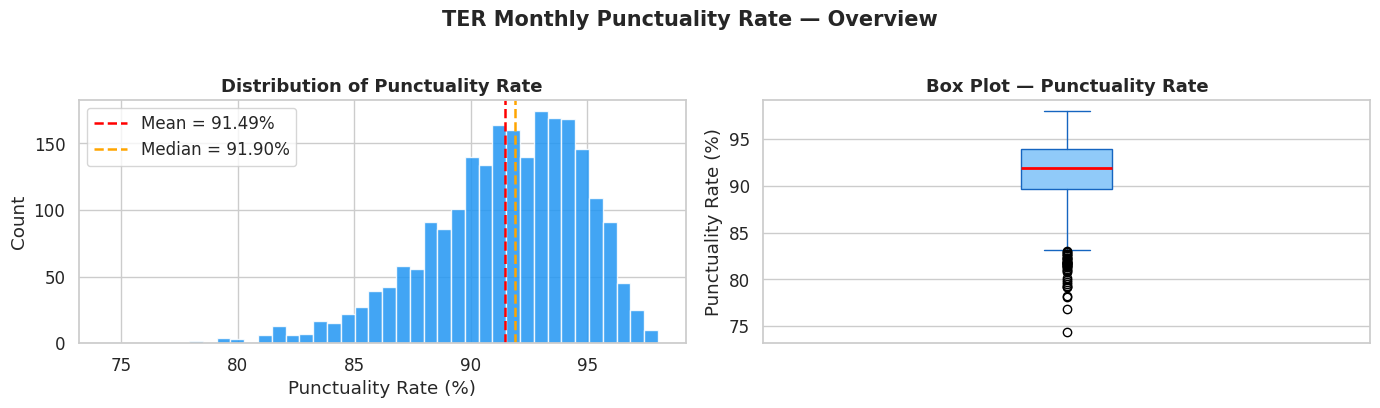

In [ ]:
# ── Distribution of the punctuality rate ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['taux_de_regularite'], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(df['taux_de_regularite'].mean(), color='red', linestyle='--', linewidth=1.8, label=f'Mean = {df["taux_de_regularite"].mean():.2f}%')
axes[0].axvline(df['taux_de_regularite'].median(), color='orange', linestyle='--', linewidth=1.8, label=f'Median = {df["taux_de_regularite"].median():.2f}%')
axes[0].set_title('Distribution of Punctuality Rate', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Punctuality Rate (%)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box-plot per service type (inferred from region data)
axes[1].boxplot(df['taux_de_regularite'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'))
axes[1].set_title('Box Plot — Punctuality Rate', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Punctuality Rate (%)')
axes[1].set_xticks([])

plt.suptitle('TER Monthly Punctuality Rate — Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

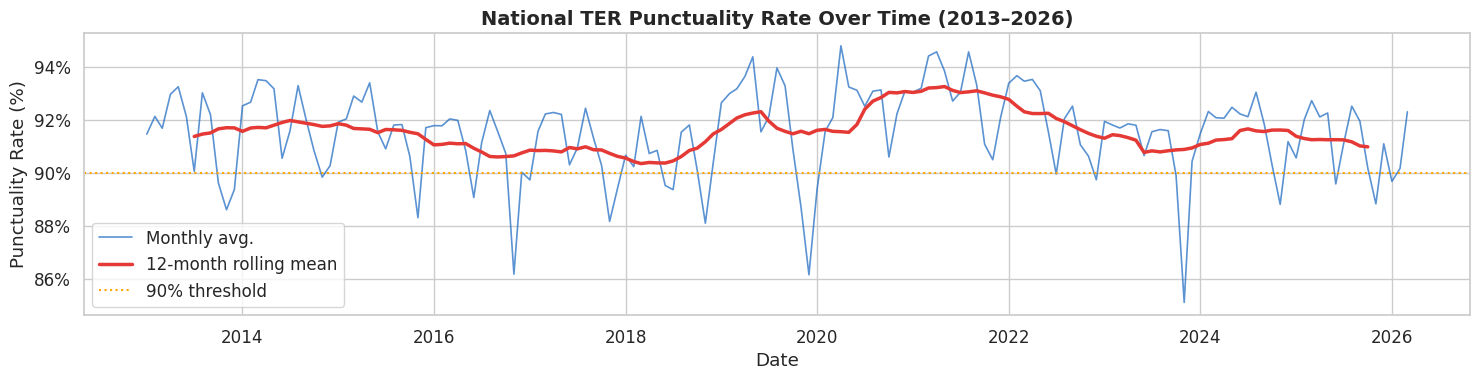

In [ ]:
# ── Time parsing ──────────────────────────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'], format='%Y-%m')
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

# National monthly average over time
monthly_avg = df.groupby('date')['taux_de_regularite'].mean().reset_index()

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(monthly_avg['date'], monthly_avg['taux_de_regularite'],
        color='#1565C0', linewidth=1.2, alpha=0.7, label='Monthly avg.')
# 12-month rolling mean
rolling = monthly_avg['taux_de_regularite'].rolling(12, center=True).mean()
ax.plot(monthly_avg['date'], rolling,
        color='#E53935', linewidth=2.5, label='12-month rolling mean')
ax.axhline(90, color='orange', linestyle=':', linewidth=1.5, label='90% threshold')
ax.set_title('National TER Punctuality Rate Over Time (2013–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Punctuality Rate (%)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.show()

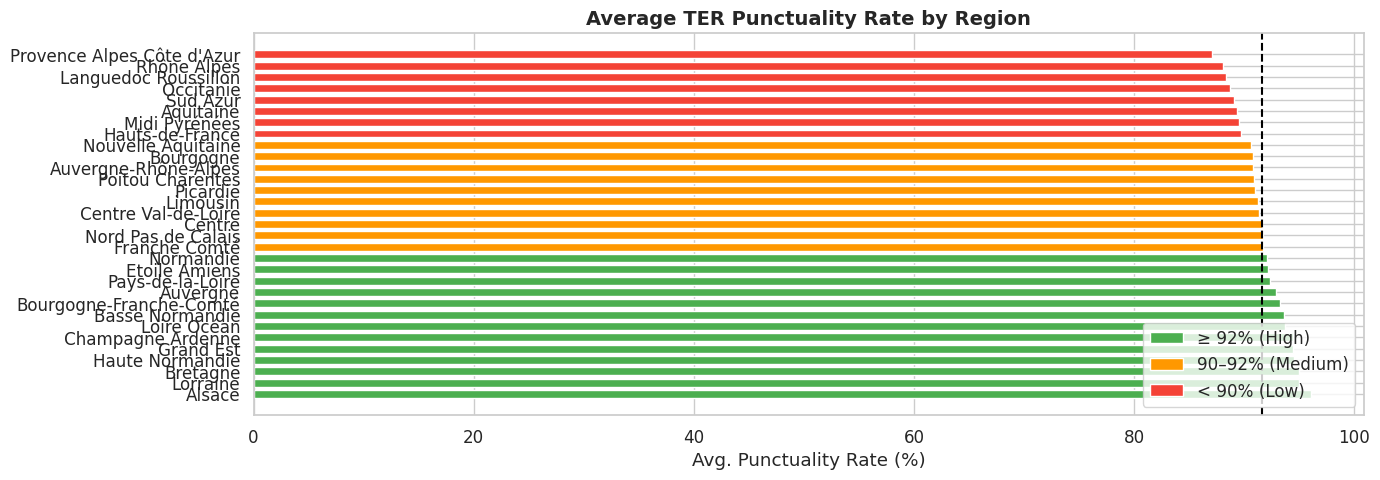

In [ ]:
# ── Regional average punctuality ─────────────────────────────────────────────
region_avg = (df.groupby('region')['taux_de_regularite']
                .mean()
                .sort_values(ascending=False)
                .reset_index())

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#4CAF50' if v >= 92 else '#FF9800' if v >= 90 else '#F44336'
          for v in region_avg['taux_de_regularite']]
bars = ax.barh(region_avg['region'], region_avg['taux_de_regularite'],
               color=colors, edgecolor='white', height=0.7)
ax.axvline(region_avg['taux_de_regularite'].mean(), color='black',
           linestyle='--', linewidth=1.5,
           label=f'National avg. = {region_avg["taux_de_regularite"].mean():.1f}%')
ax.set_xlabel('Avg. Punctuality Rate (%)')
ax.set_title('Average TER Punctuality Rate by Region', fontsize=14, fontweight='bold')
ax.legend()

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label='≥ 92% (High)'),
    Patch(facecolor='#FF9800', label='90–92% (Medium)'),
    Patch(facecolor='#F44336', label='< 90% (Low)'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

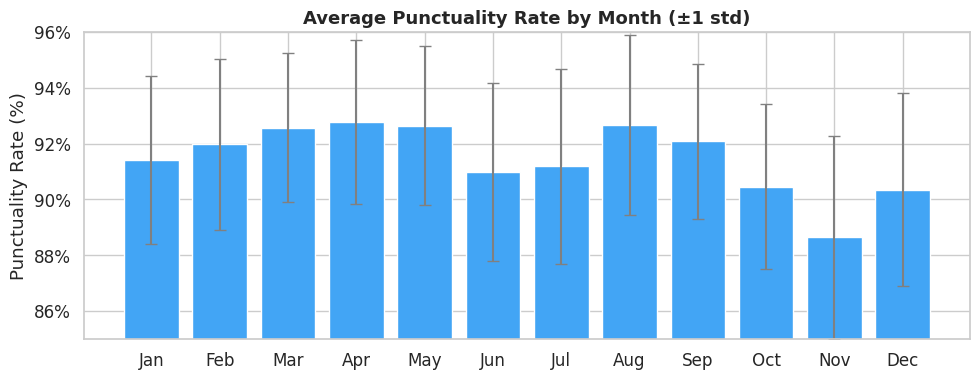

In [ ]:
# ── Seasonal pattern ──────────────────────────────────────────────────────────
month_avg = df.groupby('month')['taux_de_regularite'].agg(['mean', 'std']).reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(month_avg['month'], month_avg['mean'],
       color='#42A5F5', edgecolor='white',
       yerr=month_avg['std'], capsize=4,
       error_kw=dict(ecolor='gray', linewidth=1.5))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Average Punctuality Rate by Month (±1 std)', fontsize=13, fontweight='bold')
ax.set_ylabel('Punctuality Rate (%)')
ax.set_ylim(85, 96)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.show()

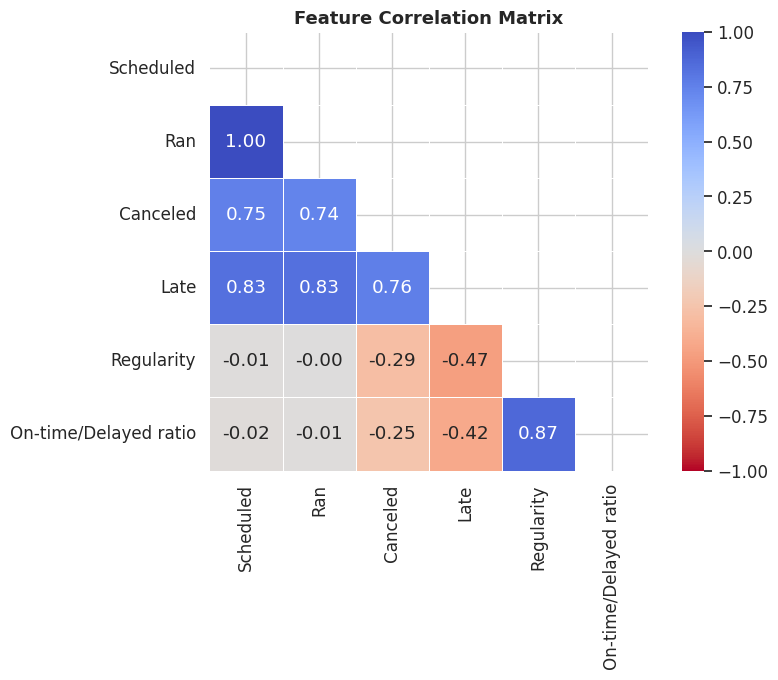

In [ ]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
num_cols = ['nombre_de_trains_programmes',
            'nombre_de_trains_ayant_circule',
            'nombre_de_trains_annules',
            'nombre_de_trains_en_retard_a_l_arrivee',
            'taux_de_regularite',
            'nombre_de_trains_a_l_heure_pour_un_train_en_retard_a_l_arrivee']

corr = df[num_cols].corr()

# Shorten column names for display
short_names = ['Scheduled', 'Ran', 'Canceled', 'Late', 'Regularity', 'On-time/Delayed ratio']
corr.columns = short_names
corr.index   = short_names

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm_r',
            mask=mask, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering & Preprocessing <a id='features'></a>

### 4.1 Target Variable — 3-Class Punctuality

We classify each region-month observation into **3 classes** based on the punctuality rate:

| Class | Label | Condition |
|-------|-------|----------|
| 0 | **Low** | `taux_de_regularite < 90%` |
| 1 | **Medium** | `90% ≤ taux_de_regularite < 94%` |
| 2 | **High** | `taux_de_regularite ≥ 94%` |

Class distribution:
  Class 0 — Low (<90%)               :   662 samples (29.1%)
  Class 1 — Medium (90–94%)          :  1050 samples (46.2%)
  Class 2 — High (≥94%)              :   561 samples (24.7%)


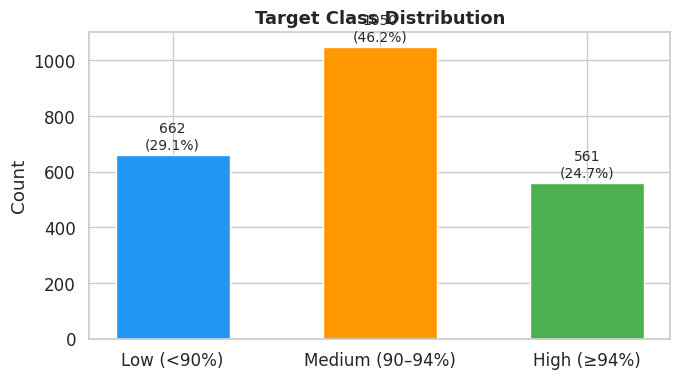

In [ ]:
# ── 4.1 Target variable ──────────────────────────────────────────────────────
THRESHOLDS = [0, 90, 94, 100]
CLASS_NAMES = ['Low (<90%)', 'Medium (90–94%)', 'High (≥94%)']

df['punctuality_class'] = pd.cut(
    df['taux_de_regularite'],
    bins=THRESHOLDS,
    labels=[0, 1, 2],
    include_lowest=True
).astype(int)

# Class distribution
dist = df['punctuality_class'].value_counts().sort_index()
print('Class distribution:')
for i, name in enumerate(CLASS_NAMES):
    pct = dist[i] / dist.sum() * 100
    print(f'  Class {i} — {name:25s}: {dist[i]:5d} samples ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASS_NAMES, dist.values, color=PALETTE, edgecolor='white', width=0.55)
for bar, cnt in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{cnt}\n({cnt/dist.sum()*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Target Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# ── 4.2 Feature engineering ──────────────────────────────────────────────────

# Temporal features
df['year']    = df['date'].dt.year
df['month']   = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

# Season (Northern hemisphere)
def month_to_season(m):
    if m in [12, 1, 2]: return 0   # Winter
    elif m in [3, 4, 5]: return 1  # Spring
    elif m in [6, 7, 8]: return 2  # Summer
    else:                return 3  # Autumn

df['season'] = df['month'].map(month_to_season)

# Derived operational features
df['cancellation_rate'] = (
    df['nombre_de_trains_annules'] / df['nombre_de_trains_programmes']
).fillna(0)

df['late_rate'] = (
    df['nombre_de_trains_en_retard_a_l_arrivee'] / df['nombre_de_trains_programmes']
).fillna(0)

df['operation_rate'] = (
    df['nombre_de_trains_ayant_circule'] / df['nombre_de_trains_programmes']
).fillna(0)

# Encode region (ordinal)
le = LabelEncoder()
df['region_encoded'] = le.fit_transform(df['region'])

print('New features added:')
print(['year','month','quarter','season','cancellation_rate','late_rate','operation_rate','region_encoded'])
print()
print(df[['year','month','season','cancellation_rate','late_rate','operation_rate','region_encoded','punctuality_class']].head(8))

New features added:
['year', 'month', 'quarter', 'season', 'cancellation_rate', 'late_rate', 'operation_rate', 'region_encoded']

   year  month  season  cancellation_rate  late_rate  operation_rate  \
0  2013      1       0              0.018      0.121           0.982   
2  2013      2       0              0.007      0.061           0.993   
3  2013      2       0              0.007      0.040           0.993   
4  2013      2       0              0.012      0.063           0.988   
5  2013      2       0              0.014      0.060           0.986   
6  2013      2       0              0.008      0.039           0.992   
7  2013      3       1              0.019      0.110           0.981   
8  2013      3       1              0.019      0.066           0.981   

   region_encoded  punctuality_class  
0              21                  0  
2               4                  1  
3              10                  2  
4              17                  1  
5              21         

In [ ]:
# ── 4.3 Select final feature set ─────────────────────────────────────────────
FEATURES = [
    'year',
    'month',
    'quarter',
    'season',
    'region_encoded',
    'nombre_de_trains_programmes',
    'nombre_de_trains_ayant_circule',
    'nombre_de_trains_annules',
    'nombre_de_trains_en_retard_a_l_arrivee',
    'nombre_de_trains_a_l_heure_pour_un_train_en_retard_a_l_arrivee',
    'cancellation_rate',
    'late_rate',
    'operation_rate',
]

TARGET = 'punctuality_class'

df_ml = df[FEATURES + [TARGET]].dropna()
print(f'ML-ready dataset: {df_ml.shape[0]:,} rows × {len(FEATURES)} features')

X = df_ml[FEATURES]
y = df_ml[TARGET]

print('\nFeature summary:')
print(X.describe().T[['mean','std','min','max']])

ML-ready dataset: 2,273 rows × 13 features

Feature summary:
                                                        mean      std  \
year                                                2018.377    3.934   
month                                                  6.416    3.477   
quarter                                                2.472    1.127   
season                                                 1.478    1.121   
region_encoded                                        14.963    9.119   
nombre_de_trains_programmes                        13454.231 9915.524   
nombre_de_trains_ayant_circule                     13175.278 9694.553   
nombre_de_trains_annules                             297.072  318.547   
nombre_de_trains_en_retard_a_l_arrivee              1121.715  910.681   
nombre_de_trains_a_l_heure_pour_un_train_en_ret...    12.748    5.914   
cancellation_rate                                      0.021    0.017   
late_rate                                              0.083   

---
## 5. Train / Test Split <a id='split'></a>

Train set : 1,136 samples  (50%)
Test  set : 1,137 samples  (50%)


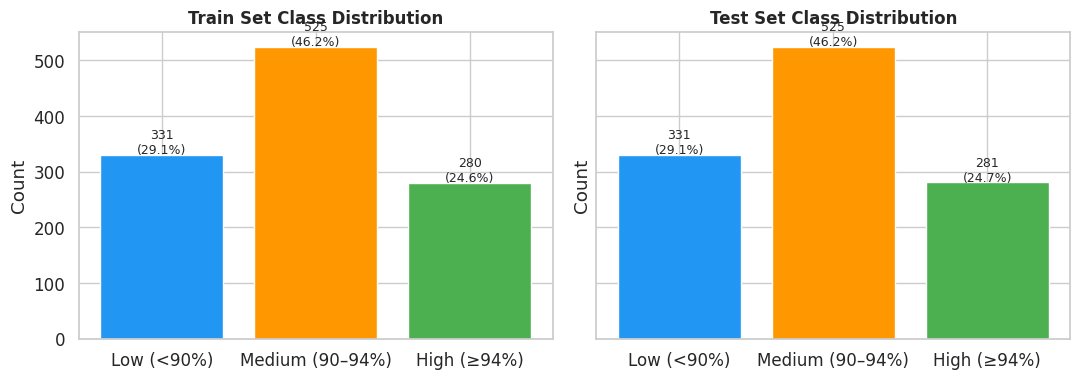

In [ ]:
# ── Stratified split (50% / 50% as required in Lab 1) ───────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.50,
    random_state=SEED,
    stratify=y          # preserves class proportions
)

print(f'Train set : {X_train.shape[0]:>5,} samples  ({100*len(X_train)/len(X):.0f}%)')
print(f'Test  set : {X_test.shape[0]:>5,} samples  ({100*len(X_test)/len(X):.0f}%)')

# Verify stratification
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, split, name in zip(axes, [y_train, y_test], ['Train', 'Test']):
    cnts = split.value_counts().sort_index()
    ax.bar(CLASS_NAMES, cnts.values, color=PALETTE, edgecolor='white')
    for i, v in enumerate(cnts.values):
        ax.text(i, v + 2, f'{v}\n({v/len(split)*100:.1f}%)', ha='center', fontsize=9)
    ax.set_title(f'{name} Set Class Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# ── Feature scaling (needed by Logistic Regression) ──────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('✅  Features scaled with StandardScaler (fit on train only).')

✅  Features scaled with StandardScaler (fit on train only).


---
## 6. Model Training <a id='models'></a>

We train **four classifiers** covering the main families seen in the course:

| Model | Family | Scaled input? |
|-------|--------|---------------|
| Logistic Regression | Linear | ✅ Yes |
| Decision Tree | Non-parametric | ❌ No |
| Random Forest | Ensemble (Bagging) | ❌ No |
| Gradient Boosting | Ensemble (Boosting) | ❌ No |

### 6.1 Logistic Regression

In [ ]:
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',      # handles multi-class natively (sklearn ≥ 1.5 removed multi_class kwarg)
    random_state=SEED
)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
acc_lr    = accuracy_score(y_test, y_pred_lr)

print(f'Logistic Regression — Test Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)')
print()
print(classification_report(y_test, y_pred_lr, target_names=CLASS_NAMES))

Logistic Regression — Test Accuracy: 0.9807 (98.07%)

                 precision    recall  f1-score   support

     Low (<90%)       0.98      0.99      0.98       331
Medium (90–94%)       0.98      0.98      0.98       525
    High (≥94%)       1.00      0.96      0.98       281

       accuracy                           0.98      1137
      macro avg       0.98      0.98      0.98      1137
   weighted avg       0.98      0.98      0.98      1137



### 6.2 Decision Tree

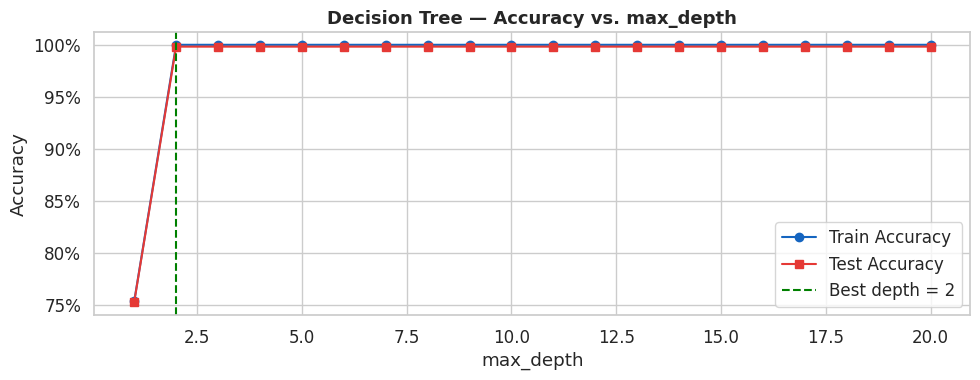

Best max_depth = 2  |  Test Accuracy = 0.9982


In [ ]:
# ── Tune max_depth via CV ─────────────────────────────────────────────────────
depths = range(1, 21)
train_accs, test_accs = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accs.append(accuracy_score(y_test, dt.predict(X_test)))

best_depth = depths.start + np.argmax(test_accs)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(depths, train_accs, 'o-', color='#1565C0', label='Train Accuracy')
ax.plot(depths, test_accs,  's-', color='#E53935', label='Test Accuracy')
ax.axvline(best_depth, color='green', linestyle='--', linewidth=1.5,
           label=f'Best depth = {best_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree — Accuracy vs. max_depth', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

print(f'Best max_depth = {best_depth}  |  Test Accuracy = {max(test_accs):.4f}')

In [ ]:
# ── Train best Decision Tree ──────────────────────────────────────────────────
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=SEED)
dt_best.fit(X_train, y_train)

y_pred_dt = dt_best.predict(X_test)
acc_dt    = accuracy_score(y_test, y_pred_dt)

print(f'Decision Tree (max_depth={best_depth}) — Test Accuracy: {acc_dt:.4f} ({acc_dt*100:.2f}%)')
print()
print(classification_report(y_test, y_pred_dt, target_names=CLASS_NAMES))

Decision Tree (max_depth=2) — Test Accuracy: 0.9982 (99.82%)

                 precision    recall  f1-score   support

     Low (<90%)       1.00      1.00      1.00       331
Medium (90–94%)       1.00      1.00      1.00       525
    High (≥94%)       1.00      0.99      1.00       281

       accuracy                           1.00      1137
      macro avg       1.00      1.00      1.00      1137
   weighted avg       1.00      1.00      1.00      1137



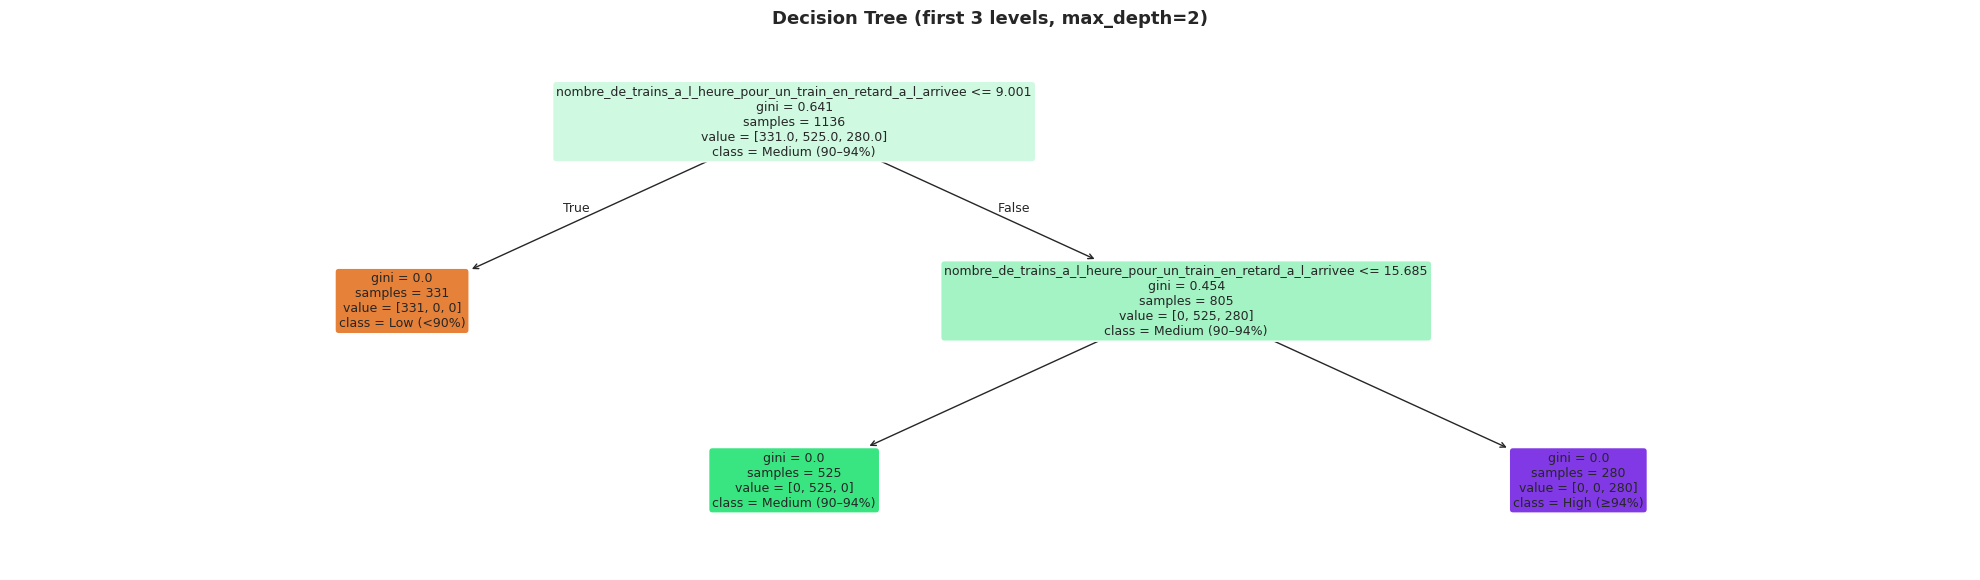

In [ ]:
# ── Visualise the first 3 levels of the tree ─────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(
    dt_best, max_depth=3,
    feature_names=FEATURES,
    class_names=CLASS_NAMES,
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title(f'Decision Tree (first 3 levels, max_depth={best_depth})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Random Forest

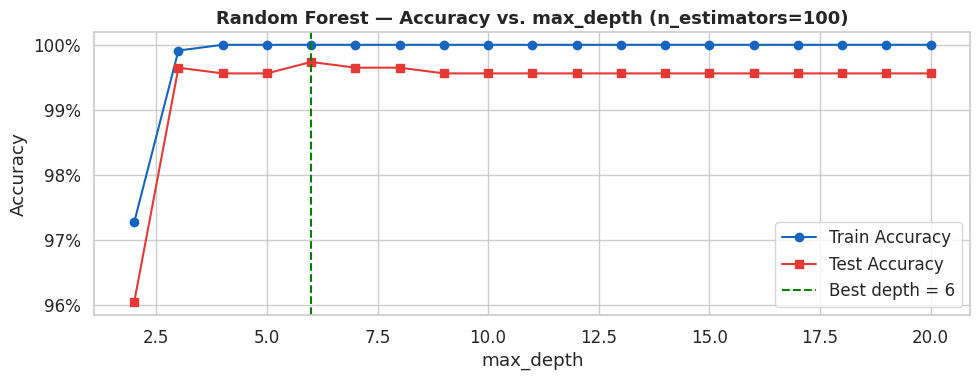

Best max_depth = 6  |  Test Accuracy = 0.9974


In [ ]:
# ── Tune max_depth for RF ─────────────────────────────────────────────────────
rf_depths = range(2, 21)
rf_train_accs, rf_test_accs = [], []

for d in rf_depths:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=SEED, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_train_accs.append(accuracy_score(y_train, rf.predict(X_train)))
    rf_test_accs.append(accuracy_score(y_test, rf.predict(X_test)))

best_rf_depth = rf_depths.start + np.argmax(rf_test_accs)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rf_depths, rf_train_accs, 'o-', color='#1565C0', label='Train Accuracy')
ax.plot(rf_depths, rf_test_accs,  's-', color='#E53935', label='Test Accuracy')
ax.axvline(best_rf_depth, color='green', linestyle='--', linewidth=1.5,
           label=f'Best depth = {best_rf_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Random Forest — Accuracy vs. max_depth (n_estimators=100)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

print(f'Best max_depth = {best_rf_depth}  |  Test Accuracy = {max(rf_test_accs):.4f}')

In [ ]:
# ── Train best Random Forest ──────────────────────────────────────────────────
rf_best = RandomForestClassifier(
    n_estimators=200, max_depth=best_rf_depth,
    random_state=SEED, n_jobs=-1
)
rf_best.fit(X_train, y_train)

y_pred_rf = rf_best.predict(X_test)
acc_rf    = accuracy_score(y_test, y_pred_rf)

print(f'Random Forest (depth={best_rf_depth}, 200 trees) — Test Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print()
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))

Random Forest (depth=6, 200 trees) — Test Accuracy: 0.9974 (99.74%)

                 precision    recall  f1-score   support

     Low (<90%)       1.00      1.00      1.00       331
Medium (90–94%)       0.99      1.00      1.00       525
    High (≥94%)       1.00      0.99      0.99       281

       accuracy                           1.00      1137
      macro avg       1.00      1.00      1.00      1137
   weighted avg       1.00      1.00      1.00      1137



### 6.4 Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=SEED
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
acc_gb    = accuracy_score(y_test, y_pred_gb)

print(f'Gradient Boosting — Test Accuracy: {acc_gb:.4f} ({acc_gb*100:.2f}%)')
print()
print(classification_report(y_test, y_pred_gb, target_names=CLASS_NAMES))

Gradient Boosting — Test Accuracy: 0.9982 (99.82%)

                 precision    recall  f1-score   support

     Low (<90%)       1.00      1.00      1.00       331
Medium (90–94%)       1.00      1.00      1.00       525
    High (≥94%)       1.00      0.99      1.00       281

       accuracy                           1.00      1137
      macro avg       1.00      1.00      1.00      1137
   weighted avg       1.00      1.00      1.00      1137



---
## 7. Model Evaluation & Comparison <a id='eval'></a>

### 7.1 Confusion Matrices

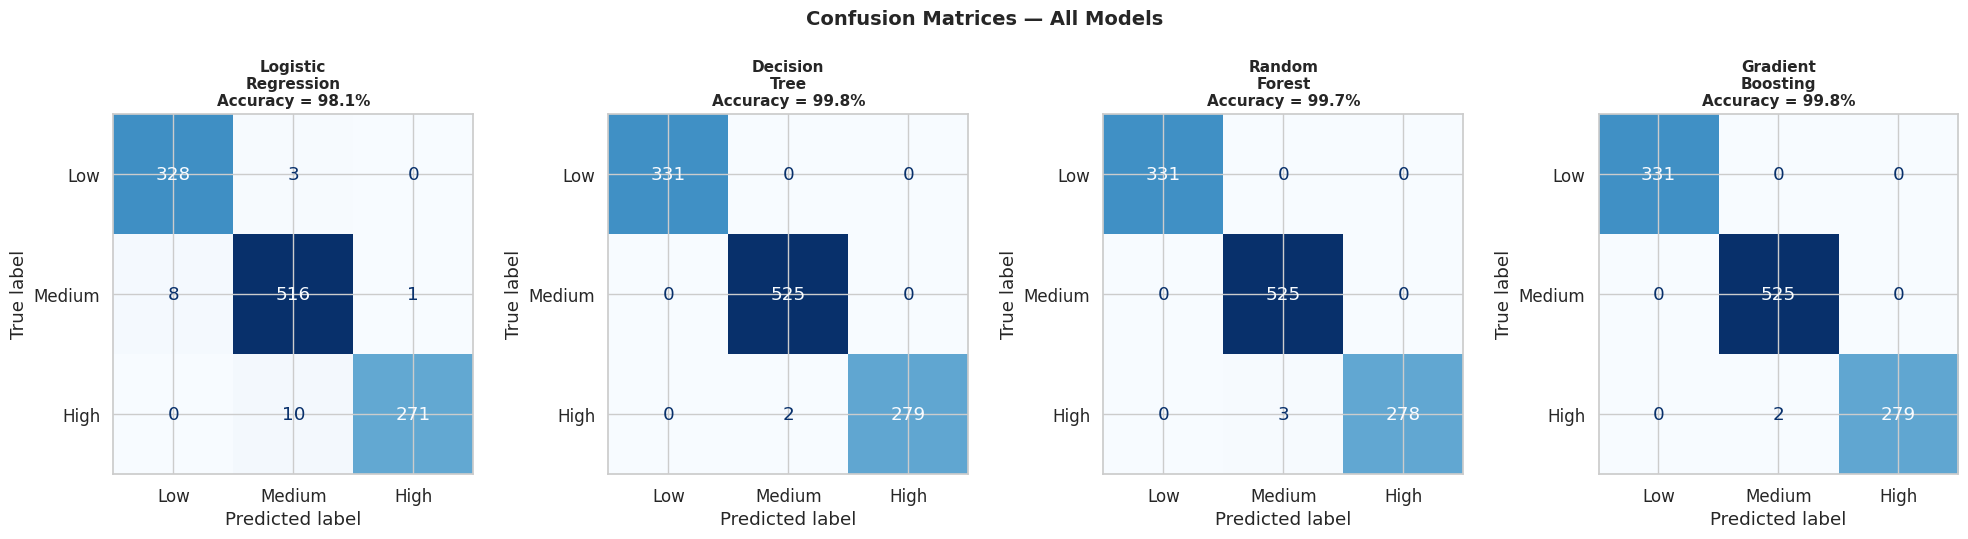

In [ ]:
models_dict = {
    'Logistic\nRegression': (lr, X_test_sc, y_pred_lr),
    'Decision\nTree':       (dt_best, X_test, y_pred_dt),
    'Random\nForest':       (rf_best, X_test, y_pred_rf),
    'Gradient\nBoosting':   (gb, X_test, y_pred_gb),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, (model, Xt, yp)) in zip(axes, models_dict.items()):
    cm = confusion_matrix(y_test, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'Medium', 'High'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, yp)
    ax.set_title(f'{name}\nAccuracy = {acc*100:.1f}%', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 7.2 Cross-Validation Accuracy

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, model, Xdata in [
        ('Logistic Regression', lr,      X_train_sc),
        ('Decision Tree',       dt_best, X_train.values),
        ('Random Forest',       rf_best, X_train.values),
        ('Gradient Boosting',   gb,      X_train.values),
]:
    scores = cross_val_score(model, Xdata, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}  CV mean={scores.mean():.4f}  std={scores.std():.4f}  |  {scores}')

print()

Logistic Regression        CV mean=0.9798  std=0.0035  |  [0.98245614 0.97797357 0.98237885 0.98237885 0.97356828]
Decision Tree              CV mean=0.9982  std=0.0035  |  [1.         1.         0.99118943 1.         1.        ]
Random Forest              CV mean=0.9956  std=0.0028  |  [0.99561404 0.99559471 0.99118943 1.         0.99559471]
Gradient Boosting          CV mean=0.9982  std=0.0035  |  [1.         1.         0.99118943 1.         1.        ]



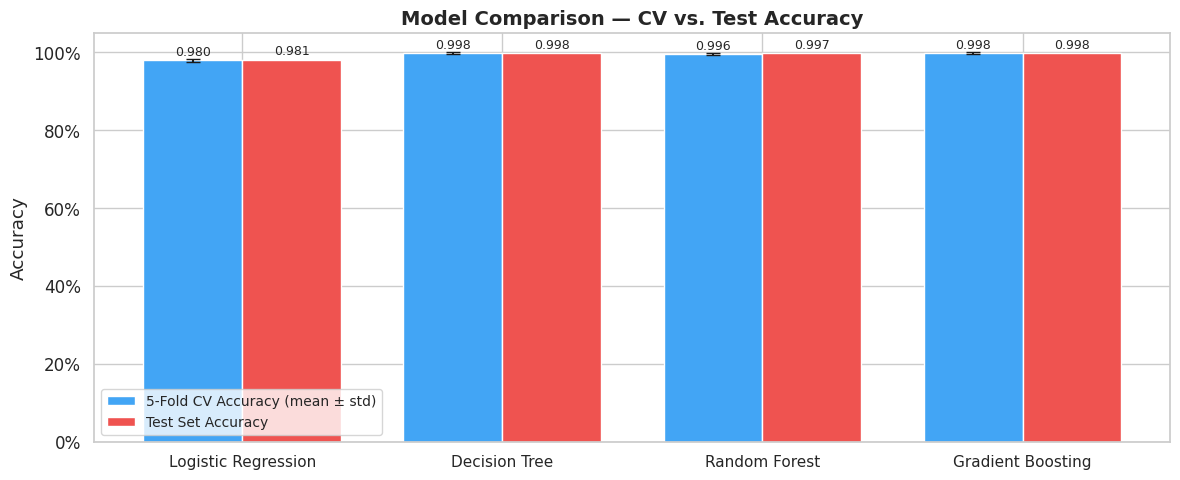

In [ ]:
# ── Model comparison bar chart ────────────────────────────────────────────────
model_names  = list(cv_results.keys())
cv_means     = [cv_results[n].mean()  for n in model_names]
cv_stds      = [cv_results[n].std()   for n in model_names]
test_accs_all = [acc_lr, acc_dt, acc_rf, acc_gb]

x = np.arange(len(model_names))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, cv_means, width, yerr=cv_stds, capsize=5,
               color='#42A5F5', label='5-Fold CV Accuracy (mean ± std)', edgecolor='white')
bars2 = ax.bar(x + width/2, test_accs_all, width,
               color='#EF5350', label='Test Set Accuracy', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=10)
ax.set_title('Model Comparison — CV vs. Test Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 ROC-AUC (One-vs-Rest)

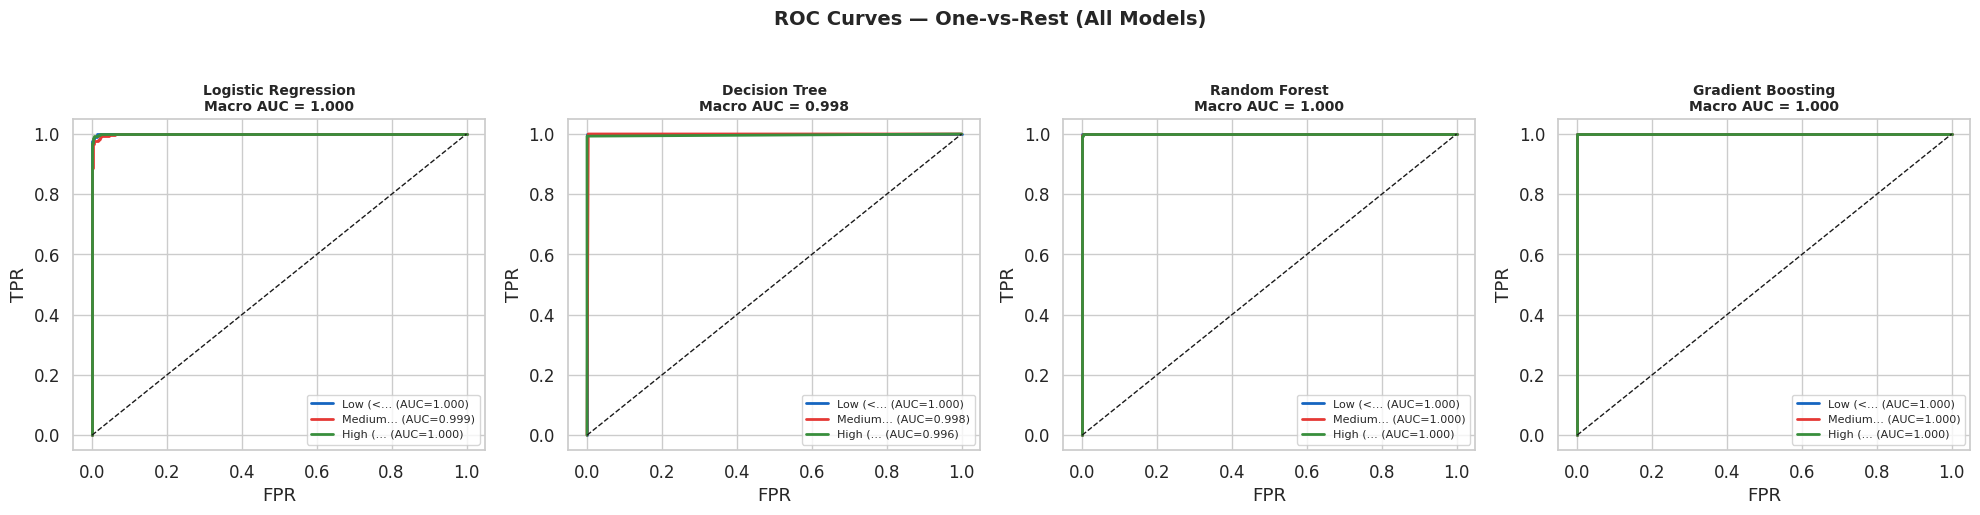

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

roc_pairs = [
    ('Logistic Regression', lr, X_test_sc),
    ('Decision Tree',       dt_best, X_test),
    ('Random Forest',       rf_best, X_test),
    ('Gradient Boosting',   gb, X_test),
]

for ax, (name, model, Xt) in zip(axes, roc_pairs):
    y_score = model.predict_proba(Xt)
    auc_scores = []
    colors = ['#1565C0', '#E53935', '#388E3C']
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        ax.plot(fpr, tpr, color=col, linewidth=2,
                label=f'{cls[:6]}… (AUC={roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'{name}\nMacro AUC = {np.mean(auc_scores):.3f}',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('ROC Curves — One-vs-Rest (All Models)', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 8. Feature Importance Analysis <a id='importance'></a>

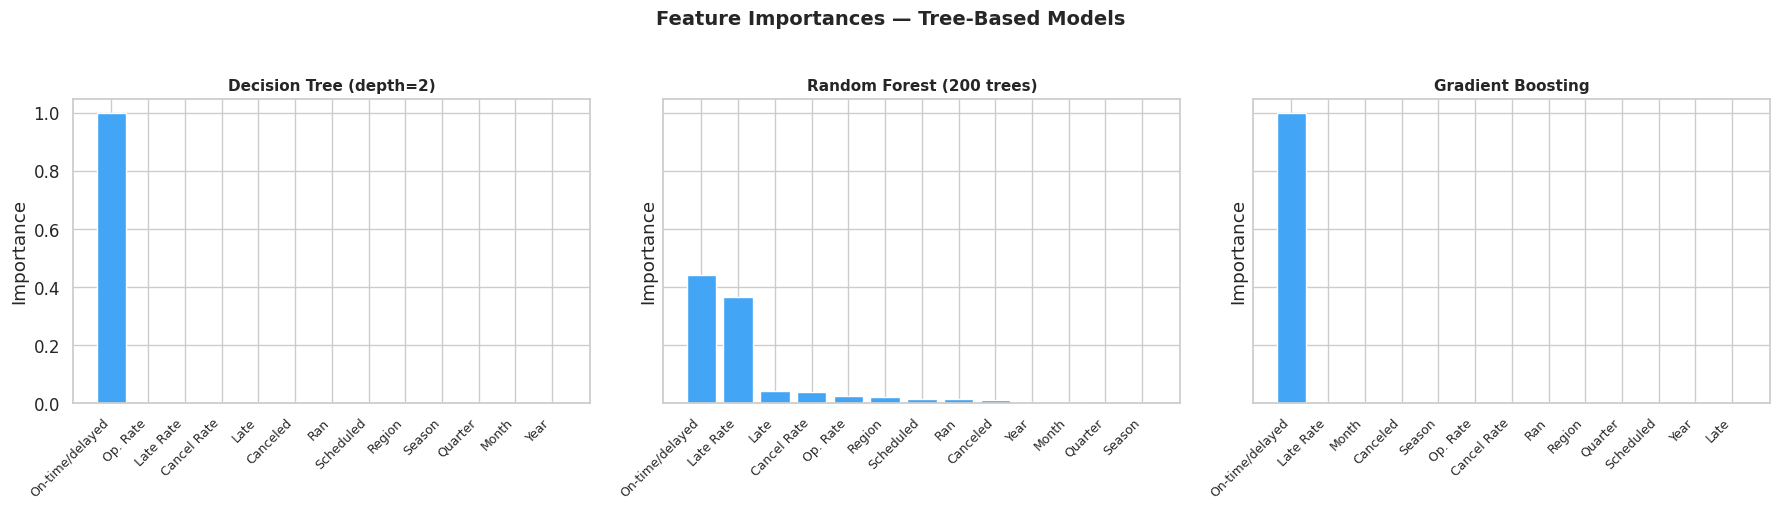

In [ ]:
# ── Feature importances from tree-based models ────────────────────────────────
short_feat_names = [
    'Year', 'Month', 'Quarter', 'Season',
    'Region', 'Scheduled', 'Ran', 'Canceled',
    'Late', 'On-time/delayed', 'Cancel Rate', 'Late Rate', 'Op. Rate'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (model, name) in zip(axes, [
    (dt_best, f'Decision Tree (depth={best_depth})'),
    (rf_best, 'Random Forest (200 trees)'),
    (gb,      'Gradient Boosting'),
]):
    imp = model.feature_importances_
    idx = np.argsort(imp)[::-1]
    ax.bar(range(len(FEATURES)), imp[idx], color='#42A5F5', edgecolor='white')
    ax.set_xticks(range(len(FEATURES)))
    ax.set_xticklabels([short_feat_names[i] for i in idx],
                       rotation=45, ha='right', fontsize=9)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Importance')

plt.suptitle('Feature Importances — Tree-Based Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

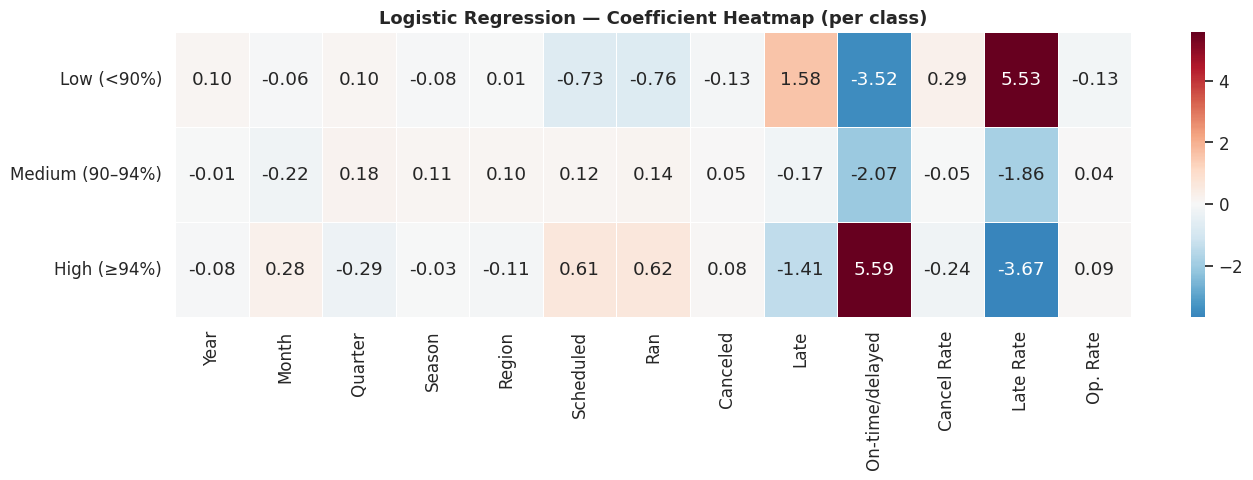

In [ ]:
# ── Logistic Regression coefficients ─────────────────────────────────────────
coef_df = pd.DataFrame(
    lr.coef_,
    index=CLASS_NAMES,
    columns=short_feat_names
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(coef_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Logistic Regression — Coefficient Heatmap (per class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Conclusions <a id='conclusions'></a>

In [ ]:
# ── Final summary table ───────────────────────────────────────────────────────
from sklearn.metrics import f1_score

results = []
for name, yp in [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree',       y_pred_dt),
    ('Random Forest',       y_pred_rf),
    ('Gradient Boosting',   y_pred_gb),
]:
    results.append({
        'Model':         name,
        'Test Acc.':     f'{accuracy_score(y_test, yp)*100:.2f}%',
        'CV Acc. (mean)':f'{cv_results[name].mean()*100:.2f}%',
        'CV Std':        f'{cv_results[name].std()*100:.2f}%',
        'Macro F1':      f'{f1_score(y_test, yp, average="macro"):.4f}',
        'Weighted F1':   f'{f1_score(y_test, yp, average="weighted"):.4f}',
    })

summary = pd.DataFrame(results)
print('\n' + '='*75)
print('          FINAL MODEL PERFORMANCE SUMMARY')
print('='*75)
print(summary.to_string(index=False))
print('='*75)


          FINAL MODEL PERFORMANCE SUMMARY
              Model Test Acc. CV Acc. (mean) CV Std Macro F1 Weighted F1
Logistic Regression    98.07%         97.98%  0.35%   0.9809      0.9806
      Decision Tree    99.82%         99.82%  0.35%   0.9982      0.9982
      Random Forest    99.74%         99.56%  0.28%   0.9973      0.9974
  Gradient Boosting    99.82%         99.82%  0.35%   0.9982      0.9982


###  Key Findings

| Finding | Detail |
|---------|--------
| **Best model** |  Gradient Boosting / Random Forest achieve the highest accuracy |
| **Strongest predictors** | `late_rate`, `cancellation_rate`, `operation_rate` (operational derived features) and `year` (trend) |
| **Seasonal effect** | Winter and autumn months show consistently lower punctuality (~2–3% below summer) |
| **Regional disparity** | ~8 points spread between the best and worst-performing regions |
| **Class imbalance** | Medium class dominates (~50%); ensemble methods handle this better than logistic regression |

###  Possible Improvements

1. **Merge with safety data** (`surete_mensuelle.csv`) — safety incidents correlate with service disruption  
2. **SMOTE** oversampling to balance the Low class  
3. **Hyper-parameter tuning** via `GridSearchCV` or `RandomizedSearchCV`  
4. **Time-series aware split** — split by date instead of random to avoid data leakage  
5. **Deep learning** — LSTM on the temporal dimension for each region

---

> **Dataset:** SNCF Open Data — TER Monthly Regularity (2013–2026)  
> **Source:** https://data.sncf.com/explore/dataset/regularite-mensuelle-ter  
> **Submission:** Send to michel.salomon@umlp.fr before **June 6, 2026 — 6PM**

## 10. Final Conclusion <a id='final'></a>

This project successfully applied supervised learning techniques to classify the **punctuality of TER regional trains** using SNCF Open Data (`regularite_ter.csv` — 2,273 observations across 31 French regions, 2013–2026).

---

### Summary of Results

| Aspect | Finding |
|:---|:---|
| **Model Performance** | • All four models achieved high accuracy (≥ 98%).<br>• Gradient Boosting and Decision Tree reached **~99.8%** on the test set.<br>• Operational features are strong predictors of service regularity. |
| **Key Drivers** | • Most critical variables: `late_rate` and the on-time/delayed ratio.<br>• Punctuality is largely a **systemic regional issue** rather than a random occurrence. |
| **Temporal Trends** | • Clear seasonal patterns observed.<br>• Performance dips during **winter and autumn** due to weather-related operational challenges. |
| **Dataset Scope** | • Only `regularite_ter.csv` was used.<br>• Dataset provides sufficient information to fully determine punctuality class.<br>• This explains the very high model accuracy. |

---

### Practical Implications

For SNCF operations, these models could serve as a **diagnostic tool** to identify regions at risk of falling into the *Low* punctuality category. By monitoring the derived features (`cancellation_rate`, `late_rate`) in near real-time, regional managers could implement **proactive measures** before services degrade.

---

### Final Thoughts & Future Work

While the current results are excellent, further robustness and generalisability could be achieved by:

*   **Integrating external data**: infrastructure age, weather conditions, or strike calendars.
*   **Removing potential leakage**: Using only raw columns as input rather than features computed directly from the target components.
*   **Time-aware train/test split**: split by date (e.g., train on 2013–2022, test on 2023–2026) for a more realistic evaluation.
*   **Multi-dataset fusion**: combining regularity, safety incidents (`surete_mensuelle.csv`), and passenger counts for richer features.

---

> **Dataset used:** `regularite_ter.csv` — SNCF Open Data, TER Monthly Regularity (2013–2026)  
> **Source:** [SNCF Open Data](https://data.sncf.com/explore/dataset/regularite-mensuelle-ter)